# Regressão 01 - tarefa 01

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import statsmodels.formula.api as smf

# Para gráficos dentro do notebook
%matplotlib inline

In [16]:
tips = sns.load_dataset("tips")

# cria conta líquida (sem a gorjeta)
tips['net_bill'] = tips['total_bill'] - tips['tip']

# cria percentual da gorjeta em relação à conta líquida
tips['tip_pct'] = tips['tip'] / tips['net_bill']

tips.head()

,total_bill,tip,sex,smoker,day,time,size,net_bill,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,15.98,0.063204
1,10.34,1.66,Male,No,Sun,Dinner,3,8.68,0.191244
2,21.01,3.50,Male,No,Sun,Dinner,3,17.51,0.199886
3,23.68,3.31,Male,No,Sun,Dinner,2,20.37,0.162494
4,24.59,3.61,Female,No,Sun,Dinner,4,20.98,0.172069


### 1. Explorando a base de gorjetas

a. Na aula fizemos uma regressão de ```tip``` explicada por ```net_bill```. Carregue os pacotes e a base, crie as variáveis necessárias como na aula, e reproduza esta regressão.

b. Reproduza também o gráfico de dispersão dessas duas variáveis.

In [17]:
reg1 = smf.ols('tip ~ net_bill', data=tips).fit()
reg1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    tip   R-squared:                       0.333
Model:                            OLS   Adj. R-squared:                  0.330
Method:                 Least Squares   F-statistic:                     120.6
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           5.02e-23
Time:                        17:48:11   Log-Likelihood:                -375.63
No. Observations:                 244   AIC:                             755.3
Df Residuals:                     242   BIC:                             762.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.3307      0.168      7.907      0.000       0.999       1.662
net_bill       0.0993      0.009     10.980      0.000       0.082       0.117
==============================================================================
Omnibus:                       33.873   Durbin-Watson:                   2.123
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               59.942
Skew:                           0.754   Prob(JB):                     9.63e-14
Kurtosis:                       4.903   Cond. No.                         43.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

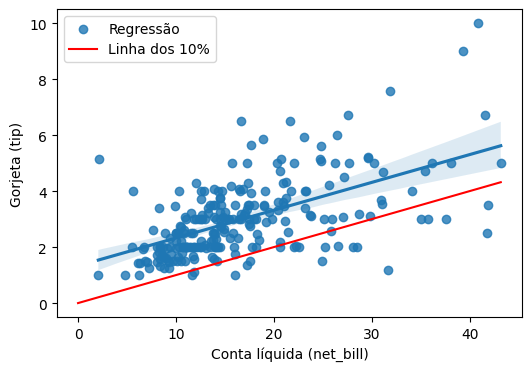

In [18]:
plt.figure(figsize=(6,4))
sns.regplot(x='net_bill', y='tip', data=tips, label='Regressão')

x = np.linspace(0, tips['net_bill'].max(), 100)
y = 0.10 * x
plt.plot(x, y, 'r-', label='Linha dos 10%')

plt.xlabel('Conta líquida (net_bill)')
plt.ylabel('Gorjeta (tip)')
plt.legend()
plt.show()

### 2. Mudança de perspectiva

Agora ajuste um modelo de regressão de ```tip_pct``` por ```net_bill```. Construa o gráfico de dispersão correspondente.

In [19]:
reg2 = smf.ols('tip_pct ~ net_bill', data=tips).fit()
reg2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                tip_pct   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     24.31
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           1.52e-06
Time:                        17:48:11   Log-Likelihood:                 108.00
No. Observations:                 244   AIC:                            -212.0
Df Residuals:                     242   BIC:                            -205.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.3053      0.023     13.166      0.000       0.260       0.351
net_bill      -0.0061      0.001     -4.931      0.000      -0.009      -0.004
==============================================================================
Omnibus:                      468.674   Durbin-Watson:                   1.987
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           234437.604
Skew:                          11.104   Prob(JB):                         0.00
Kurtosis:                     153.221   Cond. No.                         43.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

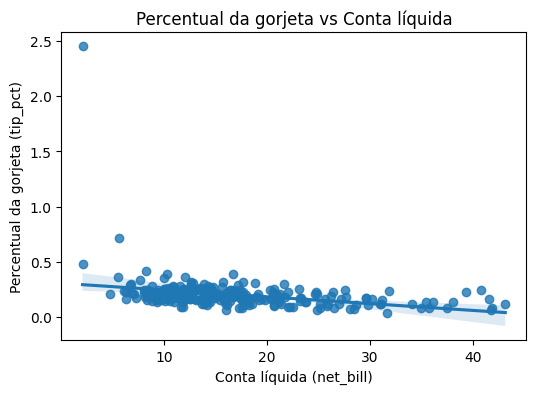

In [20]:
plt.figure(figsize=(6,4))
sns.regplot(x='net_bill', y='tip_pct', data=tips)
plt.xlabel('Conta líquida (net_bill)')
plt.ylabel('Percentual da gorjeta (tip_pct)')
plt.title('Percentual da gorjeta vs Conta líquida')
plt.show()

### 3. Comente

Compare os dois gráficos e comente (de forma objetiva e suscinta) a relação entre eles e a diferença do ajuste. Podemos comparar diretamente os $R^2$s?

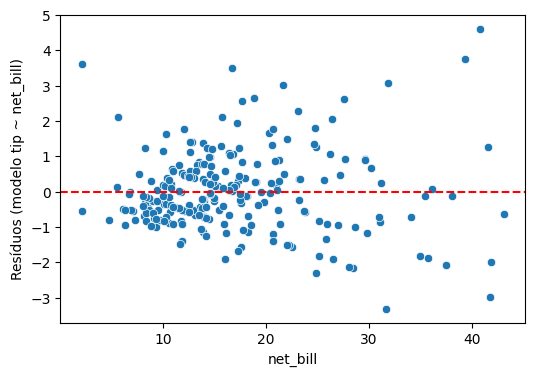

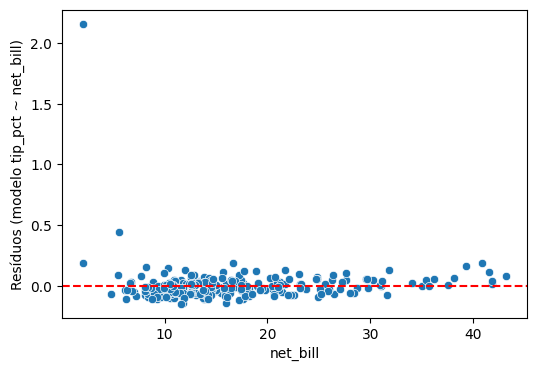

In [21]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=tips['net_bill'], y=reg1.resid)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('net_bill')
plt.ylabel('Resíduos (modelo tip ~ net_bill)')
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x=tips['net_bill'], y=reg2.resid)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('net_bill')
plt.ylabel('Resíduos (modelo tip_pct ~ net_bill)')
plt.show()

Nos dois primeiros itens eu ajustei um modelo com tip em função de net_bill e depois um modelo com tip_pct em função de net_bill, e fiz os gráficos de dispersão com as retas ajustadas.

No primeiro gráfico (gorjeta em reais vs conta líquida), a relação é claramente crescente e aproximadamente linear: conforme a conta aumenta, o valor da gorjeta também aumenta, e os pontos ficam relativamente próximos da reta. No segundo gráfico (percentual da gorjeta vs conta líquida), os pontos ficam mais espalhados e a relação com net_bill é bem menos clara, em alguns trechos até parecendo que o percentual tende a cair levemente para contas maiores.

Em relação ao ajuste, o modelo tip ~ net_bill tem um R² que mede quanta variação do valor da gorjeta em reais é explicada pela conta líquida. Já o modelo tip_pct ~ net_bill tem um R² que mede quanta variação do percentual de gorjeta é explicada por net_bill. Como são variáveis resposta diferentes (reais vs percentual), esses R² não são diretamente comparáveis para dizer “este modelo é melhor que o outro”; cada um responde a uma pergunta diferente.

### 4. Ajuste do modelo em outra escala

Com o modelo no item 3, obtenha a preditiva do valor da gorjeta:
  1. obtenha o valor predito ```pred``` para ```tip_pct``` (dica, veja o atributo ```reg.fittedvalues```)
  2. obtenha o valor predito para ```tip``` como ```tip_pct * net_bill```
  3. calcule o $R^2$ do modelo para ```tip```
  4. compare esse $R^2$ com o do item 1

In [22]:
tips['pred_tip_pct'] = reg2.fittedvalues
tips[['tip_pct', 'pred_tip_pct']].head()

,tip_pct,pred_tip_pct
0,0.063204,0.207087
1,0.191244,0.251951
2,0.199886,0.197684
3,0.162494,0.180107
4,0.172069,0.176358


In [23]:
tips['pred_tip_from_pct'] = tips['pred_tip_pct'] * tips['net_bill']
tips[['tip', 'pred_tip_from_pct']].head()

,tip,pred_tip_from_pct
0,1.01,3.309254
1,1.66,2.186938
2,3.50,3.461450
3,3.31,3.668785
4,3.61,3.699998


In [24]:
y_obs = tips['tip']                  # valores reais de gorjeta
y_pred = tips['pred_tip_from_pct']   # gorjeta predita via modelo em tip_pct

SSE = ((y_obs - y_pred) ** 2).sum()                      # soma dos quadrados dos resíduos
SST = ((y_obs - y_obs.mean()) ** 2).sum()                # soma total dos quadrados
R2_tip_via_pct = 1 - SSE / SST

R2_tip_via_pct

np.float64(0.10889974845461325)

In [25]:
R2_direct = reg1.rsquared
R2_direct, R2_tip_via_pct

(np.float64(0.3325407312323706), np.float64(0.10889974845461325))